In [1]:
import torch
import torch.nn as nn

import torch_geometric as tg
import torch_geometric.utils as tgu
import torch_geometric.nn as tgnn
import matplotlib.pyplot as plt

import numpy as np

## Notes from graphcast
 - there are multiple layers of nodes -> some nodes propagate information to more distant nodes
 - loss function takes into account multiple factors - e.g. sample density
 - autoregressive training 
   - model is trained using fix interval
   - to predict more distant (in time) points then previous prediction of a model is used
   - predicting 10 day ahead tends to have large overfitting
 - gnn was selected because weather function is the same in every place of the globe

In [2]:
omega = 1.8

feature_vec_len = 8
x = np.arange(0,6.4,0.1).reshape((-1,1))
t = np.arange(0,6,0.1).reshape([-1,1])

values = np.sin(omega*t+x.T)

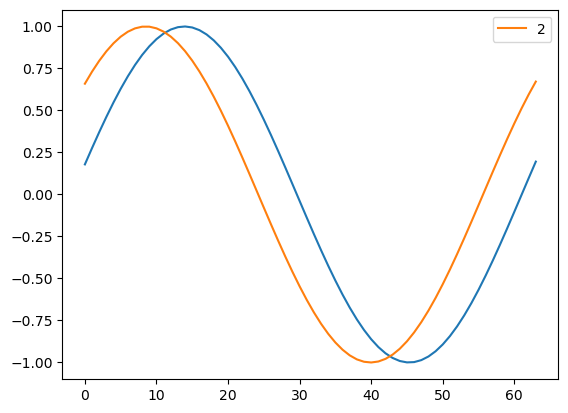

In [5]:
plt.plot(values[1,:])
plt.plot(values[4,:], label='2')
plt.legend()

In [74]:
def get_sample(values, dt=4, inclusion_prob=0.5):
    time_horizon, positions = values.shape

    fully_connected_adj = torch.ones(positions, positions)
    fully_connected = tgu.dense_to_sparse(fully_connected_adj)[0]

    sample = []
    sample_dt = []

    time_stamp = np.random.randint(time_horizon - dt)

    is_included = np.random.random(positions) > inclusion_prob
    for idx, included in zip(range(positions), is_included):
        sample.append((
            idx/positions,
            included*1.0,
            values[time_stamp, idx] * included,
        ))
        sample_dt.append((
            idx/positions,
            1.0,
            values[time_stamp + dt, idx],
        ))

    return (
        torch.tensor(sample, dtype=torch.float32, requires_grad=False),
        torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),
        torch.tensor(sample_dt, dtype=torch.float32, requires_grad=False)
    )

In [75]:
class feature_encoder(nn.Module):
    def __init__(self, dims=None, output_feature_num=feature_vec_len):
        nn.Module.__init__(self)

        if dims is None:
            self.dims = {
                "time": 1,
                "x_pos": 1,
                "value": 1,
            } 
        else:
            self.dims = dims

        self.input_dimensionality = sum(self.dims.values())

        self.seq = nn.Sequential(
            nn.Linear(self.input_dimensionality, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU(),
            nn.Linear(32, output_feature_num),
            nn.Tanh()
        )

    def forward(self, x):
        return self.seq(x)

In [76]:
fe_model = feature_encoder()
te = feature_encoder({'time': 1}, output_feature_num=16)
sample = get_sample(values)
fe_model(sample[0])

/tmp/ipykernel_84582/3835534236.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),


tensor([[-1.4278e-01, -1.4030e-01, -8.1530e-03, -1.4433e-01, -7.2646e-02,
         -8.1093e-03,  1.4421e-01, -6.1205e-02],
        [-8.8980e-02, -1.2059e-01, -2.8517e-02, -1.5547e-01, -7.9961e-02,
         -5.1070e-02,  1.4718e-01, -1.1866e-01],
        [-8.8979e-02, -1.2049e-01, -2.8485e-02, -1.5530e-01, -8.0121e-02,
         -5.1366e-02,  1.4679e-01, -1.1870e-01],
        [-8.8982e-02, -1.2040e-01, -2.8448e-02, -1.5514e-01, -8.0280e-02,
         -5.1664e-02,  1.4641e-01, -1.1875e-01],
        [-1.6279e-01, -1.3686e-01, -5.1222e-03, -1.3033e-01, -6.0457e-02,
         -1.4039e-02,  1.3674e-01, -4.4678e-02],
        [-1.6731e-01, -1.3620e-01, -4.0647e-03, -1.2767e-01, -5.7837e-02,
         -1.5603e-02,  1.3502e-01, -4.1207e-02],
        [-1.7152e-01, -1.3563e-01, -2.9676e-03, -1.2537e-01, -5.5452e-02,
         -1.7138e-02,  1.3338e-01, -3.8061e-02],
        [-8.9036e-02, -1.2012e-01, -2.8244e-02, -1.5454e-01, -8.0923e-02,
         -5.2868e-02,  1.4485e-01, -1.1886e-01],
        [-8.9061

In [83]:
# x_cord, y_cord, time
# time_embed 


class gnn_model(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)
        self.gnn_out_ch = 32
        self.edge_vector_len = 16
        edge_params_shape = values.shape[1]**2
        #self.fe = feature_encoder()
        self.edge_params = nn.Parameter(torch.randn([edge_params_shape, self.edge_vector_len])/20)

        self.l1 = tgnn.GAT(
            in_channels=3,#feature_vec_len,
            hidden_channels=4*feature_vec_len,
            num_layers=3,
            out_channels=self.gnn_out_ch,
            dropout=0.1,
            act='gelu',
            edge_dim=self.edge_vector_len,
            v2=True,
        )
        self.l2 = nn.Linear(self.gnn_out_ch, 2)

    def forward(self, nodes, edges):
        encoded_features = nodes#self.fe(nodes)

        g_output = self.l1(encoded_features, edges, edge_attr=self.edge_params)
        dense_output = self.l2(g_output)

        return dense_output



In [84]:
model = gnn_model()

In [85]:
model(
    sample[0],
    sample[1],
).shape

torch.Size([64, 2])

In [86]:
sample[1][0]

tensor([ 0,  0,  0,  ..., 63, 63, 63])

In [87]:
NUM_TR_STEPS = 1024*32
loss_t_0 = []
loss_t_dt = []
optimizer = torch.optim.AdamW(model.parameters(),lr=1e-2,)
loss_fn = nn.MSELoss()

for i in range(NUM_TR_STEPS):
    sample = get_sample(values)

    y_hat = model(
        sample[0],
        sample[1],
    )

    loss = loss_fn(sample[2][:,-1:], y_hat[:,-1:])
    
    # check if this is correct place for zero grad
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if i%10 == 0:
        l_dt = ((sample[2][:,-1] - y_hat[:,-1])**2).T
        loss_t_dt.append(l_dt.detach())
        print(f"l_dt:{torch.mean(l_dt)}")



/tmp/ipykernel_84582/3835534236.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),


l_dt:0.49588534235954285
l_dt:0.49457085132598877
l_dt:0.5082319378852844
l_dt:0.500800609588623
l_dt:0.4915037751197815
l_dt:0.5036760568618774
l_dt:0.5012272000312805
l_dt:0.5086204409599304
l_dt:0.4926106929779053
l_dt:0.5084104537963867
l_dt:0.4921615421772003
l_dt:0.5038172006607056
l_dt:0.49115651845932007
l_dt:0.49486681818962097
l_dt:0.4935891926288605
l_dt:0.4994890093803406
l_dt:0.4909086525440216
l_dt:0.5016876459121704
l_dt:0.5074299573898315
l_dt:0.4998232126235962
l_dt:0.5069743990898132
l_dt:0.4936223030090332
l_dt:0.5004764199256897
l_dt:0.5039219856262207
l_dt:0.510394811630249
l_dt:0.4915156960487366
l_dt:0.5014539957046509
l_dt:0.5088625550270081
l_dt:0.4983309209346771
l_dt:0.509245753288269
l_dt:0.4916534423828125
l_dt:0.5081241726875305
l_dt:0.5025604963302612
l_dt:0.49077683687210083
l_dt:0.500167727470398
l_dt:0.4934597611427307
l_dt:0.5087667107582092
l_dt:0.5066229104995728
l_dt:0.5074303150177002
l_dt:0.5093650817871094
l_dt:0.49892690777778625
l_dt:0.5054495

KeyboardInterrupt: 

In [106]:
torch.mean((y_hat[:,-1:] - sample[2][:,-1:])**2)

tensor(0.0089, grad_fn=<MeanBackward0>)

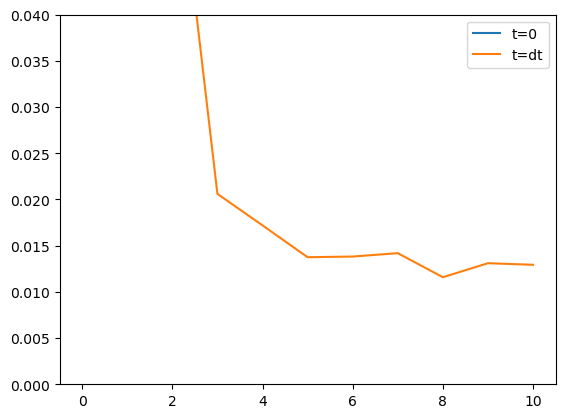

In [96]:
mean_over = 20
t0 = np.array([torch.mean(x).item() for x in loss_t_0])
t0_mean = t0[t0.shape[0]%mean_over:].reshape([-1,mean_over]).mean(axis=1)

t_dt = np.array([torch.mean(x).item() for x in loss_t_dt])
t_dt_mean = t_dt[t_dt.shape[0]%mean_over:].reshape([-1,mean_over]).mean(axis=1)

plt.plot(t0_mean, label='t=0')
plt.plot(t_dt_mean, label='t=dt')
plt.legend()
plt.ylim(0.0,.04)
plt.show()

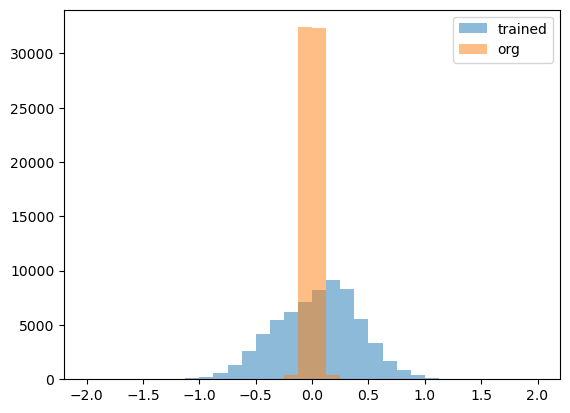

In [ ]:
plt.hist(model.edge_params.detach().flatten(), bins=32, label='trained', alpha=0.5,range=(-2,2))
plt.hist((torch.randn(model.edge_params.shape)/20).flatten(), bins=32, label='org', alpha=0.5,range=(-2,2))
plt.legend()
plt.show()